In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from amoc_analysis import data, plotting
from amocatlas import read
from spectra_filtering import analysis, spectra # sonst amocatlas.spectra_filtering


In [15]:
fig_path = "../figures/"

In [2]:
ds = read.mocha()
MOC = ds["MOC"]

Loading 1 MOCHA 26°N dataset(s):
  0. Johns_2023_mht_data_2020_ERA5.zip: No description available



/Users/jakob/Desktop/SS2026/DataAnalysis/.venv/lib/python3.13/site-packages/amocatlas/reader_utils.py:80: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(file_path, **kwargs)


In [3]:
stats = analysis.summary_stats(MOC.values)

In [18]:
stats["range"]

np.float64(37.9699772404192)

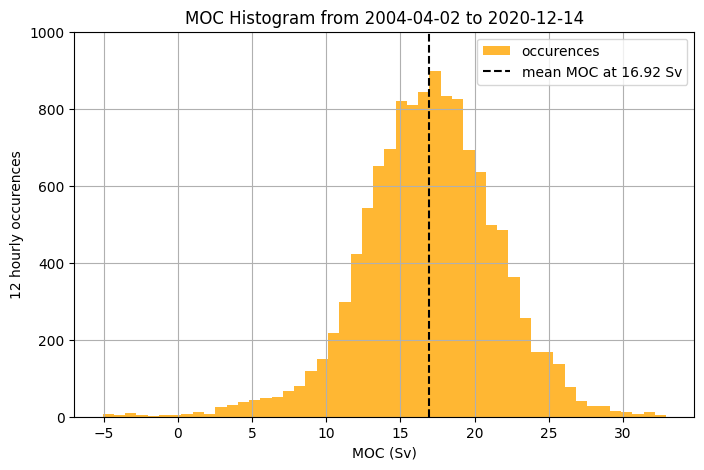

In [17]:
plt.figure(figsize=[8,5])
plt.hist(MOC, bins = 50, alpha = 0.8, color = "orange", label = "occurences")
plt.ylabel("12 hourly occurences")
plt.xlabel("MOC (Sv)")
plt.vlines(stats["mean"], 0 ,1000, ls = "--", color = "k", label = f"mean MOC at {stats["mean"]:.2f} Sv")
plt.ylim(0,1000)
plt.legend()
plt.grid()
plt.title(f"MOC Histogram from {str(MOC["TIME"].isel(TIME = 0).values)[:10]} to {str(MOC["TIME"].isel(TIME = -1).values)[:10]}")
plt.savefig(fig_path + "histogram.pdf")